# Complete Data Pipeline: Multi-Source Acquisition to ML-Ready Data

**Docker image**: `ml4t`

## Purpose
Wire together the chapter's components — multi-provider acquisition,
OHLC validation, source attribution, and efficient storage — into two
end-to-end pipelines: an equity pipeline that stitches WikiPrices
(1990-2018) with Yahoo (2018-now), and a crypto pipeline that consumes
the local Binance hourly perpetuals panel. The notebook then shows how
`ml4t.data.DataManager` collapses the same logic into a few lines.

## Learning Objectives
- Build a multi-source equity pipeline and validate at every boundary.
- Detect 24/7 coverage gaps and add session features for crypto data.
- Tag every row with its source so multi-source data is auditable.
- Replace the explicit pipeline with the `DataManager` + `Universe` +
  `HiveStorage` higher-level API that ships with `ml4t.data`.

## Book reference
Chapter 2, §2.3 (multi-source stitching + production pipelines). The
pipeline outputs feed the ETF and crypto-perps case studies.

## Prerequisites
- WikiPrices parquet under
  `ML4T_DATA_PATH/equities/market/us_equities/us_equities.parquet`.
- Crypto-perps hourly parquet loadable via `data.load_crypto_perps`.
- Live YahooFinance access (the equity pipeline calls it for the
  2018-now leg — same convention as `16_provider_comparison`).

## Note on universe choice
WikiPrices covers individual US stocks (~3,200 tickers, 1962-2018) but
**not** index ETFs. For the equity pipeline below the demo universe
uses three large-caps (AAPL, MSFT, JPM) so the WikiPrices-Yahoo stitch
is non-trivial; the ETF rotation case study itself uses Yahoo-only
from 2008 onwards (see `case_studies/etfs/`).

In [1]:
"""Complete Data Pipeline — Multi-source acquisition to ML-ready data."""

from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import polars as pl
from ml4t.data.providers import WikiPricesProvider, YahooFinanceProvider

from data import load_crypto_perps
from utils import DATA_DIR
from utils.paths import get_output_dir

# Reproducibility: a fixed AS_OF_DATE keeps outputs stable between book editions.
AS_OF_DATE = "2025-01-15"
print(f"Data path: {DATA_DIR}")

Data path: /home/stefan/ml4t/code/data


In [2]:
# Production defaults — Papermill injects overrides for CI

---

## 1. Pipeline Architecture

A production pipeline has three stages:

| Stage | Inputs | Outputs |
|-------|--------|---------|
| **Acquire** | Yahoo Finance, WikiPrices, Binance | raw OHLCV per source |
| **Process** | raw OHLCV | validated, normalized, tagged frames |
| **Store** | tagged frames | partitioned Parquet keyed by symbol/date |

Four design principles drive the rest of the notebook:

1. **Provider independence** — the orchestrator shouldn't care which
   source each row came from.
2. **Validate at boundaries** — every entry/exit point checks OHLC
   invariants, gap thresholds, and duplicate timestamps.
3. **Source attribution** — every row carries a `source` column so
   downstream debugging stays sane.
4. **Incremental updates** — re-runs fetch only what is new (the
   `DataManager` API in §5 handles this transparently).

---

## 2. Equity Pipeline (Stocks: AAPL / MSFT / JPM)

### Requirements

- **Universe**: AAPL, MSFT, JPM (chosen because they have full
  WikiPrices coverage; pure ETFs like SPY only have Yahoo data here).
- **History**: 1990-present (~35 years).
- **Frequency**: Daily.
- **Adjustments**: Split + dividend (total return).

### Combine Multi-Source Data

Wiki Prices ends at 2018-03-27; Yahoo Finance continues from there.
This function stitches the two sources at the boundary, tagging each
row with its origin for downstream auditability.

In [3]:
def _combine_pipeline_sources(
    historical: pl.DataFrame | None,
    recent: pl.DataFrame | None,
    symbol: str,
    wiki_end: str = "2018-03-27",
) -> pl.DataFrame:
    """Combine Wiki Prices and Yahoo Finance data at the provider boundary."""
    if historical is None and recent is None:
        raise ValueError(f"No data available for {symbol}")

    if historical is None:
        return recent.with_columns(pl.lit("yahoo").alias("source"))

    if recent is None:
        return historical.with_columns(pl.lit("wiki").alias("source"))

    # Both sources - combine with proper boundary
    wiki_end_dt = datetime.strptime(wiki_end, "%Y-%m-%d").date()

    historical = historical.filter(pl.col("timestamp").dt.date() <= wiki_end_dt)
    recent = recent.filter(pl.col("timestamp").dt.date() > wiki_end_dt)

    # Back-adjust the historical Wiki series for any splits that occurred AFTER
    # the Wiki cutoff (e.g., AAPL 4-for-1 on 2020-08-31). Wiki's adjusted prices
    # only back-adjust splits available within its own coverage window; Yahoo's
    # adjusted prices retroactively account for every later split. Without this
    # rescale, the stitch produces a visible step at the source boundary. We
    # rescale historical OHLC by the ratio of (Yahoo first close) / (Wiki last
    # close); both series are already dividend-adjusted, so this isolates the
    # post-boundary split factor. Volume scales inversely to price (a 4-for-1
    # split divides price by 4 and multiplies volume by 4), so the historical
    # volume column is divided by the same factor to stay consistent with
    # Yahoo's retroactively-split-adjusted volume on the recent side.
    if len(historical) > 0 and len(recent) > 0:
        wiki_last_close = historical.sort("timestamp")["close"][-1]
        yahoo_first_close = recent.sort("timestamp")["close"][0]
        if wiki_last_close and wiki_last_close > 0 and yahoo_first_close and yahoo_first_close > 0:
            scale = yahoo_first_close / wiki_last_close
            historical = historical.with_columns(
                [
                    (pl.col("open") * scale).alias("open"),
                    (pl.col("high") * scale).alias("high"),
                    (pl.col("low") * scale).alias("low"),
                    (pl.col("close") * scale).alias("close"),
                    (pl.col("volume") / scale).alias("volume"),
                ]
            )

    historical = historical.with_columns(pl.lit("wiki").alias("source"))
    recent = recent.with_columns(pl.lit("yahoo").alias("source"))

    common_cols = list(set(historical.columns) & set(recent.columns))
    combined = pl.concat([historical.select(common_cols), recent.select(common_cols)]).sort(
        "timestamp"
    )

    return combined

### Validate Pipeline Data

Check OHLC invariants, detect zero/negative prices, flag date gaps
beyond five calendar days, and catch duplicate timestamps.

In [4]:
def _validate_pipeline_data(df: pl.DataFrame, symbol: str) -> dict[str, Any]:
    """Run data quality validation checks on OHLCV data."""
    issues = []

    # OHLC invariants
    ohlc_valid = (
        (df["high"] >= df["low"]).all()
        and (df["high"] >= df["open"]).all()
        and (df["high"] >= df["close"]).all()
        and (df["low"] <= df["open"]).all()
        and (df["low"] <= df["close"]).all()
    )
    if not ohlc_valid:
        issues.append("OHLC invariant violations")

    # Zero/negative prices
    if (df["close"] <= 0).any():
        issues.append("Zero or negative prices")

    # Date gaps
    dates = df["timestamp"].sort().to_list()
    max_gap_days = max(
        (dates[i] - dates[i - 1]).days for i in range(1, len(dates)) if len(dates) > 1
    )

    if max_gap_days > 5:
        issues.append(f"Date gap of {max_gap_days} days")

    # Duplicate dates
    if df["timestamp"].n_unique() != len(df):
        issues.append(f"Duplicate dates: {len(df) - df['timestamp'].n_unique()}")

    return {
        "symbol": symbol,
        "n_rows": len(df),
        "date_range": (df["timestamp"].min(), df["timestamp"].max()),
        "max_gap_days": max_gap_days if len(dates) > 1 else 0,
        "issues": issues,
        "is_valid": len(issues) == 0,
    }

### Fetch Historical Data from Wiki Prices

Reads adjusted OHLCV from the Wiki Prices parquet, adapting to whichever
column-naming schema the on-disk file uses (`symbol`/`asset`/`ticker`).

In [5]:
def _fetch_wiki_historical(
    wiki_path: Path, symbol: str, start_date: str, end_date: str
) -> pl.DataFrame | None:
    """Fetch historical data from Wiki Prices parquet with schema auto-detection."""
    schema = set(pl.scan_parquet(wiki_path).collect_schema().names())
    start_dt = datetime.strptime(start_date, "%Y-%m-%d").date()
    end_dt = datetime.strptime(end_date, "%Y-%m-%d").date()

    # Determine entity and time column names from on-disk schema
    if "symbol" in schema:
        entity_col, time_col = "symbol", "timestamp"
    elif "asset" in schema:
        entity_col, time_col = "asset", "timestamp"
    else:
        entity_col, time_col = "ticker", "date"

    df = (
        pl.scan_parquet(wiki_path)
        .filter(
            (pl.col(entity_col) == symbol)
            & (pl.col(time_col) >= pl.lit(start_dt))
            & (pl.col(time_col) <= pl.lit(end_dt))
        )
        .select(
            [
                pl.col(time_col).cast(pl.Datetime("us")).alias("timestamp"),
                pl.col("adj_open").alias("open"),
                pl.col("adj_high").alias("high"),
                pl.col("adj_low").alias("low"),
                pl.col("adj_close").alias("close"),
                pl.col("adj_volume").alias("volume"),
            ]
        )
        .sort("timestamp")
        .collect()
    )
    return df if len(df) > 0 else None

### Process a Single ETF Symbol

Drives one symbol through fetch, combine, validate, and tag. Returns
a result dict with the data and validation report.

In [6]:
def _process_etf_symbol(
    pipeline: "ETFMomentumPipeline", symbol: str, start_date: str = "1990-01-01"
) -> dict[str, Any]:
    """Process a single symbol through the complete pipeline."""
    print(f"\n{symbol}:")

    # Stage 1: Fetch
    historical = pipeline.fetch_historical(symbol, start_date)
    recent = pipeline.fetch_recent(symbol, "2018-03-28")

    wiki_rows = len(historical) if historical is not None else 0
    yahoo_rows = len(recent) if recent is not None else 0
    print(f"  Fetched: Wiki={wiki_rows:,}, Yahoo={yahoo_rows:,}")

    # Stage 2: Combine
    try:
        combined = pipeline.combine_sources(historical, recent, symbol)
    except ValueError as e:
        return {"symbol": symbol, "error": str(e)}

    # Stage 3: Validate
    validation = _validate_pipeline_data(combined, symbol)
    if validation["issues"]:
        for issue in validation["issues"]:
            print(f"  [WARN] {issue}")
        pipeline.stats["validation_errors"] += len(validation["issues"])
    else:
        print(f"  Validated: {len(combined):,} rows, no issues")

    # Stage 4: Add metadata
    combined = combined.with_columns(
        [pl.lit(symbol).alias("symbol"), pl.lit(datetime.now()).alias("processed_at")]
    )

    pipeline.stats["symbols_processed"] += 1
    pipeline.stats["total_rows"] += len(combined)

    return {"symbol": symbol, "data": combined, "validation": validation}

### Run ETF Pipeline

Iterates over the symbol universe, processing each through fetch/combine/validate,
then prints a summary of processed symbols, total rows, and validation issues.

In [7]:
def _run_etf_pipeline(
    pipeline: "ETFMomentumPipeline", symbols: list[str] | None = None
) -> dict[str, Any]:
    """Run the complete ETF pipeline for all symbols."""
    symbols = symbols or pipeline.UNIVERSE
    print("=" * 60)
    print("ETF Momentum Pipeline")
    print("=" * 60)
    print(f"Universe: {symbols}")

    results = {}
    for symbol in symbols:
        results[symbol] = pipeline.process_symbol(symbol)

    print("\n" + "-" * 60)
    print(
        f"Summary: {pipeline.stats['symbols_processed']} symbols, "
        f"{pipeline.stats['total_rows']:,} rows, "
        f"{pipeline.stats['validation_errors']} issues"
    )
    return results

### ETF Momentum Pipeline

Orchestrates multi-source fetch (Wiki Prices + Yahoo Finance),
data combination, validation, and metadata tagging for each symbol.

In [8]:
class ETFMomentumPipeline:
    """Equity pipeline: combines WikiPrices (1962-2018) with Yahoo Finance (2018-present).

    Demo universe uses individual stocks because WikiPrices does not include
    index ETFs. The book's ETF rotation case study uses Yahoo-only data from
    2008 onwards (see `case_studies/etfs/`).
    """

    UNIVERSE = ["AAPL", "MSFT", "JPM"]
    WIKI_END_DATE = "2018-03-27"
    END_DATE = AS_OF_DATE

    def __init__(self, wiki_path: Path | None = None, storage_path: Path | None = None):
        """Initialize pipeline with data sources."""
        from utils import ML4T_DATA_PATH

        self.wiki_path = (
            wiki_path
            or ML4T_DATA_PATH / "equities" / "market" / "us_equities" / "us_equities.parquet"
        )
        self.storage_path = storage_path or get_output_dir(2, "etf_pipeline")
        self.yahoo_provider = YahooFinanceProvider()
        self.stats = {"symbols_processed": 0, "total_rows": 0, "validation_errors": 0}

    def fetch_historical(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch data from Wiki Prices (pre-2018)."""
        if not self.wiki_path.exists():
            raise FileNotFoundError(f"Wiki Prices parquet not found at {self.wiki_path}")
        return _fetch_wiki_historical(self.wiki_path, symbol, start_date, self.WIKI_END_DATE)

    def fetch_recent(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch data from Yahoo Finance (2018-present)."""
        df = self.yahoo_provider.fetch_ohlcv(
            symbol=symbol, start=start_date, end=self.END_DATE, frequency="1d"
        )
        return df if len(df) > 0 else None

    def combine_sources(
        self, historical: pl.DataFrame | None, recent: pl.DataFrame | None, symbol: str
    ) -> pl.DataFrame:
        """Combine Wiki Prices and Yahoo Finance data."""
        return _combine_pipeline_sources(historical, recent, symbol, self.WIKI_END_DATE)

    def process_symbol(self, symbol: str, start_date: str = "1990-01-01") -> dict[str, Any]:
        """Process a single symbol through the complete pipeline."""
        return _process_etf_symbol(self, symbol, start_date)

    def run(self, symbols: list[str] | None = None) -> dict[str, Any]:
        """Run the complete pipeline for all symbols."""
        return _run_etf_pipeline(self, symbols)

In [9]:
# Run the equity pipeline on the demo universe
etf_pipeline = ETFMomentumPipeline()
etf_results = etf_pipeline.run()

2026-07-11 14:27:26 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=yahoo


2026-07-11 14:27:26 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


ETF Momentum Pipeline
Universe: ['AAPL', 'MSFT', 'JPM']

AAPL:
2026-07-11 14:27:26 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=1d name=YahooFinanceProvider provider=yahoo start=2018-03-28 symbol=AAPL


2026-07-11 14:27:26 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2018-03-28 symbol=AAPL


2026-07-11 14:27:26 [info     ] Successfully fetched data      rows=1711 symbol=AAPL


...

  [WARN] Date gap of 7 days

JPM:
2026-07-11 14:27:26 [info     ] Fetching OHLCV data            end=2025-01-15 frequency=1d name=YahooFinanceProvider provider=yahoo start=2018-03-28 symbol=JPM


2026-07-11 14:27:26 [info     ] Fetching data from Yahoo Finance end=2025-01-16 interval=1d start=2018-03-28 symbol=JPM


2026-07-11 14:27:26 [info     ] Successfully fetched data      rows=1711 symbol=JPM


2026-07-11 14:27:26 [info     ] Successfully fetched OHLCV data name=YahooFinanceProvider provider=yahoo rows=1711 symbol=JPM


  Fetched: Wiki=7,114, Yahoo=1,711
  [WARN] Date gap of 7 days

------------------------------------------------------------
Summary: 3 symbols, 26,474 rows, 3 issues


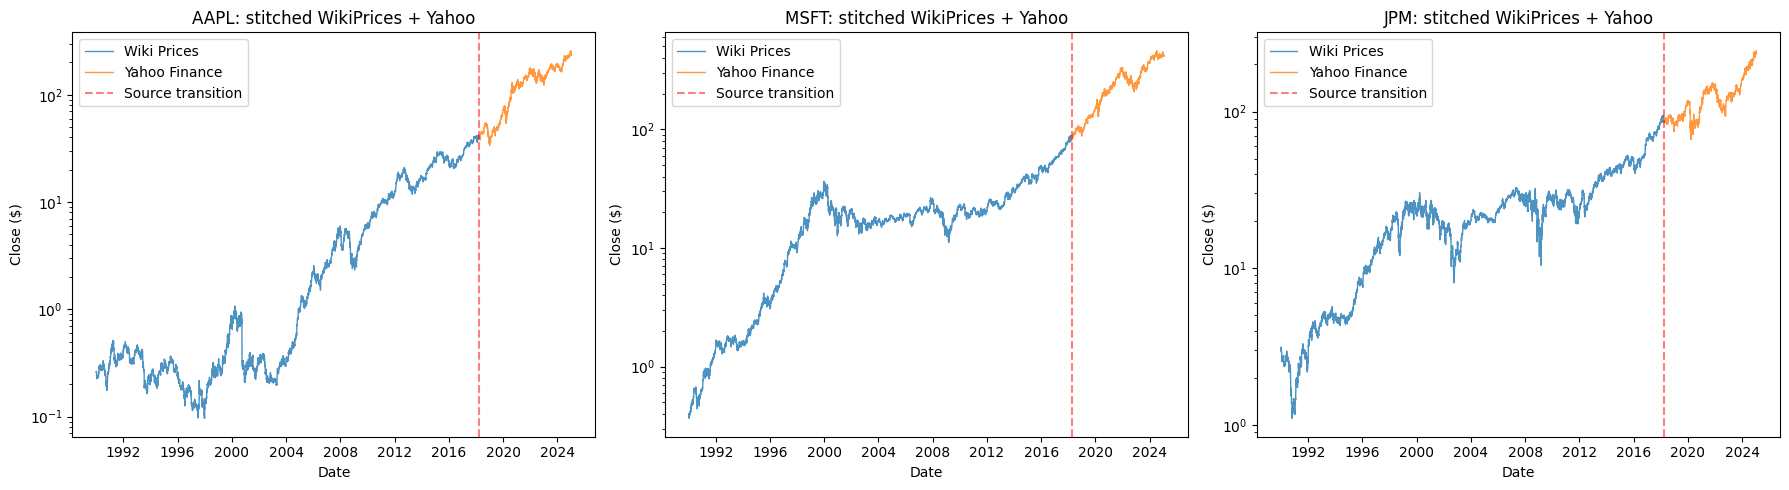

In [10]:
# Visualize the stitched data — one panel per symbol
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (symbol, result) in zip(axes, etf_results.items(), strict=True):
    df = result["data"]
    for source, color in [("wiki", "#1f77b4"), ("yahoo", "#ff7f0e")]:
        src = df.filter(pl.col("source") == source)
        label = "Wiki Prices" if source == "wiki" else "Yahoo Finance"
        if len(src) > 0:
            ax.plot(
                src["timestamp"].to_list(),
                src["close"].to_list(),
                label=label,
                alpha=0.8,
                linewidth=1,
                color=color,
            )
    ax.axvline(
        datetime(2018, 3, 27), color="red", linestyle="--", alpha=0.5, label="Source transition"
    )
    ax.set_title(f"{symbol}: stitched WikiPrices + Yahoo")
    ax.set_xlabel("Date")
    ax.set_ylabel("Close ($)")
    ax.legend(loc="upper left")
    ax.set_yscale("log")
plt.tight_layout()
plt.show()

---

## 3. Case Study 2: Crypto Funding Rate Pipeline

### Requirements

- **Universe**: BTCUSDT, ETHUSDT (perpetual futures)
- **History**: 2020-present
- **Frequency**: Hourly OHLCV
- **Coverage**: 24/7 (no market hours)

### Validate 24/7 Coverage

Crypto markets run continuously, so we check for hourly gaps rather than
the weekday/holiday gaps expected in equity data.

In [11]:
def _validate_crypto_coverage(df: pl.DataFrame, symbol: str) -> dict[str, Any]:
    """Validate 24/7 coverage for crypto data."""
    issues = []
    df = df.sort("timestamp")

    timestamps = df["timestamp"].to_list()
    expected_hours = len(timestamps) - 1 if len(timestamps) > 1 else 0
    missing_hours = 0

    for i in range(1, len(timestamps)):
        gap_hours = (timestamps[i] - timestamps[i - 1]).total_seconds() / 3600
        if gap_hours > 1.5:
            missing_hours += int(gap_hours) - 1

    coverage_pct = (
        (expected_hours - missing_hours) / expected_hours * 100 if expected_hours > 0 else 0
    )

    if coverage_pct < 99.0:
        issues.append(f"Coverage {coverage_pct:.1f}% ({missing_hours} hours missing)")

    if df["timestamp"].n_unique() != len(df):
        issues.append(f"Duplicate timestamps: {len(df) - df['timestamp'].n_unique()}")

    return {
        "symbol": symbol,
        "n_rows": len(df),
        "hours_coverage": expected_hours,
        "missing_hours": missing_hours,
        "coverage_pct": coverage_pct,
        "issues": issues,
        "is_valid": len(issues) == 0,
    }

### Add Session Features

Derive time-of-day and day-of-week columns used downstream for
funding-window analysis and weekend/weekday volume comparisons.

In [12]:
def _add_crypto_session_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add time-based features for crypto data."""
    return df.with_columns(
        [
            pl.col("timestamp").dt.hour().alias("hour_utc"),
            pl.col("timestamp").dt.weekday().alias("day_of_week"),
            (pl.col("timestamp").dt.hour() // 8 * 8).alias("funding_window"),
            pl.col("timestamp").dt.date().alias("session_date"),
            (pl.col("timestamp").dt.weekday() >= 5).alias("is_weekend"),
        ]
    )

### Process a Single Crypto Symbol

Drives one symbol through fetch, coverage validation, feature enrichment,
and source tagging. Returns a result dict with data and validation report.

In [13]:
def _process_crypto_symbol(
    pipeline: "CryptoFundingRatePipeline", symbol: str, start_date: str = "2020-01-01"
) -> dict[str, Any]:
    """Process a single crypto symbol through the pipeline."""
    print(f"\n{symbol}:")

    df = pipeline.fetch_ohlcv(symbol, start_date)
    validation = _validate_crypto_coverage(df, symbol)
    print(f"  Rows: {len(df):,}, Coverage: {validation['coverage_pct']:.1f}%")

    if validation["issues"]:
        for issue in validation["issues"]:
            print(f"  [WARN] {issue}")

    df = _add_crypto_session_features(df)
    df = df.with_columns([pl.lit(symbol).alias("symbol"), pl.lit("local").alias("source")])

    pipeline.stats["symbols_processed"] += 1
    pipeline.stats["total_rows"] += len(df)
    pipeline.stats["hours_of_data"] += validation["hours_coverage"]

    return {"symbol": symbol, "data": df, "validation": validation}

### Fetch Crypto OHLCV

Filters the pre-loaded hourly crypto DataFrame for a single symbol
starting from the requested date.

In [14]:
def _fetch_crypto_ohlcv(crypto_data: pl.DataFrame, symbol: str, start_date: str) -> pl.DataFrame:
    """Filter the hourly crypto panel for one symbol from `start_date`."""
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    df = crypto_data.filter(
        (pl.col("symbol") == symbol) & (pl.col("timestamp").dt.date() >= start_dt.date())
    ).drop("symbol")
    if df.is_empty():
        raise RuntimeError(f"No crypto data for {symbol} from {start_date}")
    return df

### Run Crypto Pipeline

Iterates over the crypto symbol universe, processing each through fetch,
validation, and feature enrichment, then prints a summary.

In [15]:
def _run_crypto_pipeline(
    pipeline: "CryptoFundingRatePipeline",
    symbols: list[str] | None = None,
    start_date: str = "2023-01-01",
) -> dict:
    """Run the complete crypto pipeline for all symbols."""
    symbols = symbols or pipeline.UNIVERSE
    print("=" * 60)
    print("Crypto Funding Rate Pipeline")
    print("=" * 60)
    print(f"Universe: {symbols}")

    results = {}
    for symbol in symbols:
        results[symbol] = pipeline.process_symbol(symbol, start_date)

    print("\n" + "-" * 60)
    print(
        f"Summary: {pipeline.stats['symbols_processed']} symbols, "
        f"{pipeline.stats['total_rows']:,} rows"
    )
    return results

### Crypto Funding Rate Pipeline

Orchestrates fetch, validation, and feature enrichment for hourly crypto
perpetual-futures data loaded from local parquet storage.

In [16]:
class CryptoFundingRatePipeline:
    """
    Data pipeline for Crypto Funding Rate strategy.

    Uses pre-downloaded hourly crypto data from local storage.
    """

    UNIVERSE = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT"]
    END_DATE = AS_OF_DATE

    def __init__(self, storage_path: Path | None = None):
        """Initialize pipeline."""
        self.storage_path = storage_path or get_output_dir(2, "crypto_pipeline")
        self.crypto_data = load_crypto_perps(frequency="1h")
        print(f"Loaded {len(self.crypto_data):,} crypto records")
        self.stats = {"symbols_processed": 0, "total_rows": 0, "hours_of_data": 0}

    def fetch_ohlcv(self, symbol: str, start_date: str) -> pl.DataFrame | None:
        """Fetch OHLCV data from local parquet."""
        return _fetch_crypto_ohlcv(self.crypto_data, symbol, start_date)

    def process_symbol(self, symbol: str, start_date: str = "2020-01-01") -> dict[str, Any]:
        """Process a single crypto symbol."""
        return _process_crypto_symbol(self, symbol, start_date)

    def run(self, symbols: list[str] | None = None, start_date: str = "2023-01-01") -> dict:
        """Run the complete pipeline."""
        return _run_crypto_pipeline(self, symbols, start_date)

In [17]:
# Run the crypto pipeline
crypto_pipeline = CryptoFundingRatePipeline()
crypto_results = crypto_pipeline.run(symbols=["BTCUSDT", "ETHUSDT"], start_date="2024-01-01")

Loaded 866,484 crypto records
Crypto Funding Rate Pipeline
Universe: ['BTCUSDT', 'ETHUSDT']

BTCUSDT:
  Rows: 17,544, Coverage: 100.0%

ETHUSDT:
  Rows: 17,544, Coverage: 100.0%

------------------------------------------------------------
Summary: 2 symbols, 35,088 rows


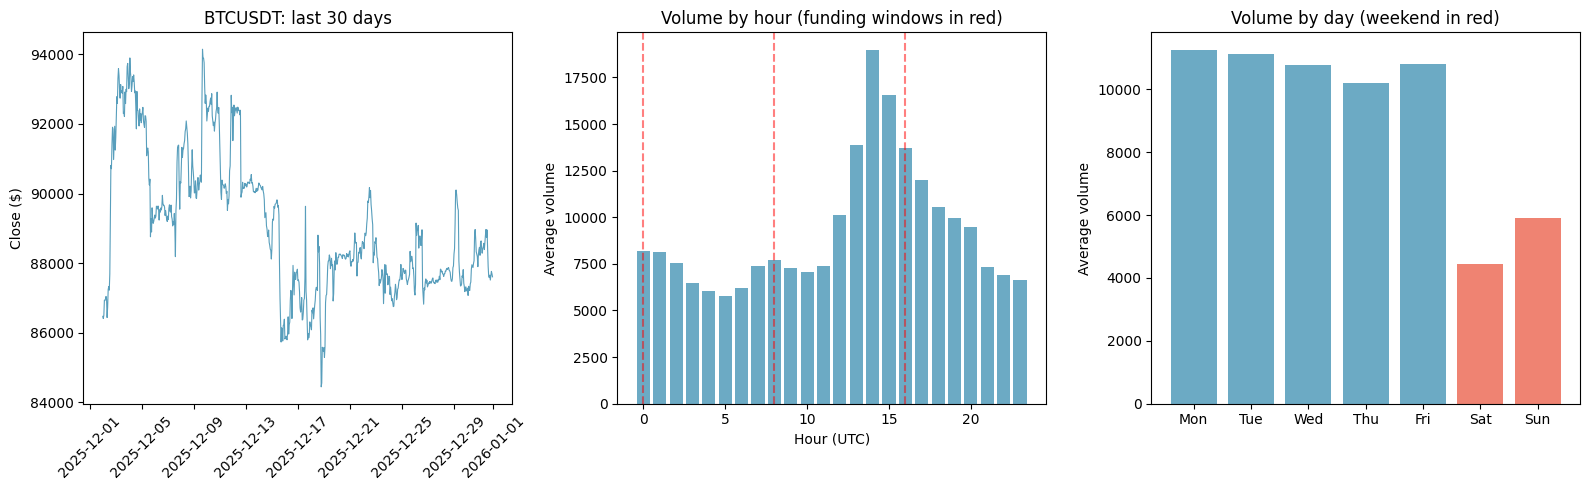

In [18]:
# Visualize crypto data patterns: price series + hourly/daily volume profile
btc_data = crypto_results["BTCUSDT"]["data"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: last 30 days of close
recent_data = btc_data.tail(24 * 30)
axes[0].plot(
    recent_data["timestamp"].to_list(),
    recent_data["close"].to_list(),
    linewidth=0.8,
    alpha=0.8,
    color="#2E86AB",
)
axes[0].set_ylabel("Close ($)")
axes[0].set_title("BTCUSDT: last 30 days")
axes[0].tick_params(axis="x", rotation=45)

# Panel 2: average volume by hour, with funding windows highlighted
hourly_volume = (
    btc_data.group_by("hour_utc").agg(pl.col("volume").mean().alias("avg_volume")).sort("hour_utc")
)
axes[1].bar(
    hourly_volume["hour_utc"].to_list(),
    hourly_volume["avg_volume"].to_list(),
    color="#2E86AB",
    alpha=0.7,
)
for funding_hour in [0, 8, 16]:
    axes[1].axvline(funding_hour, color="red", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Average volume")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_title("Volume by hour (funding windows in red)")

# Panel 3: average volume by weekday (weekend in red)
daily_volume = (
    btc_data.group_by("day_of_week")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("day_of_week")
)
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
colors = ["#2E86AB"] * 5 + ["#E94F37"] * 2
axes[2].bar(range(7), daily_volume["avg_volume"].to_list(), color=colors, alpha=0.7)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(days)
axes[2].set_ylabel("Average volume")
axes[2].set_title("Volume by day (weekend in red)")

plt.tight_layout()
plt.show()

---

## 4. Storage Best Practices

### Partitioned Parquet Storage

For large datasets, partition by time and symbol:

```
output/
└── etf_momentum/
    ├── year=2024/
    │   ├── SPY.parquet
    │   ├── QQQ.parquet
    │   └── TLT.parquet
    └── year=2023/
        └── ...
```

**Benefits**:
- **Partition pruning**: Only read needed date ranges
- **Incremental writes**: Add new data without rewriting
- **Parallel reads**: Process multiple partitions concurrently

In [19]:
# Save pipeline outputs (example)
print("Storage Example:")
print(f"  ETF output: {etf_pipeline.storage_path}")
print(f"  Crypto output: {crypto_pipeline.storage_path}")

Storage Example:
  ETF output: /home/stefan/ml4t/code/02_financial_data_universe/output/etf_pipeline
  Crypto output: /home/stefan/ml4t/code/02_financial_data_universe/output/crypto_pipeline


---

## 5. Simplifying with DataManager

The pipelines above show every step explicitly. In practice, ml4t-data's
`DataManager` and `Universe` classes handle most of this boilerplate.
Here's how the ETF pipeline looks using the higher-level API:

In [20]:
from ml4t.data import DataManager
from ml4t.data.storage import HiveStorage
from ml4t.data.storage.backend import StorageConfig
from ml4t.data.universe import Universe
from ml4t.data.update_manager import GapDetector
from ml4t.data.validation import OHLCVValidator

# One-line universe instead of hardcoded list
Universe.add_custom("etf_momentum", ["SPY", "QQQ", "IWM", "TLT", "GLD"])
print(f"Universe: {Universe.get('etf_momentum')}")

# DataManager with storage — fetch, store, and validate in one step
dm_config = StorageConfig(base_path=get_output_dir(2, "dm_pipeline"), compression="zstd")
dm_storage = HiveStorage(config=dm_config)
dm = DataManager(storage=dm_storage, enable_validation=True)

# Fetch and store all symbols
for symbol in Universe.get("etf_momentum"):
    key = dm.load(symbol, "2024-01-01", AS_OF_DATE, provider="yahoo")
    meta = dm.get_metadata(symbol)
    rows = meta.get("row_count", "?") if meta else "?"
    print(f"  {symbol}: {rows} rows → {key}")

Universe: ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD']
2026-07-11 14:27:27 [debug    ] Applied DATABENTO_API_KEY to databento.api_key


2026-07-11 14:27:27 [debug    ] Applied OANDA_API_KEY to oanda.api_key


2026-07-11 14:27:27 [debug    ] ConfigManager initialized      config_path=None output_format=polars


2026-07-11 14:27:27 [debug    ] ProviderManager initialized    available_providers=['databento', 'oanda', 'massive', 'polygon', 'okx', 'mock', 'binance_public', 'synthetic', 'yahoo', 'cryptocompare', 'binance']


2026-07-11 14:27:27 [info     ] DataManager initialized        available_providers=['databento', 'oanda', 'massive', 'polygon', 'okx', 'mock', 'binance_public', 'synthetic', 'yahoo', 'cryptocompare', 'binance'] output_format=polars storage_enabled=True validation_enabled=True


...

2026-07-11 14:27:28 [warning  ] Data already exists for equities/daily/GLD, overwriting


2026-07-11 14:27:28 [info     ] Storing data for GLD           progress=80%


2026-07-11 14:27:28 [info     ] Data load completed            key=equities/daily/GLD rows=261


2026-07-11 14:27:28 [info     ] Completed loading GLD          progress=100%


  GLD: 261 rows → equities/daily/GLD


In [21]:
# Validate and check gaps — compare to the manual validate_data() above
validator = OHLCVValidator(max_return_threshold=0.5)
gap_detector = GapDetector(exclude_weekends=True)

for symbol in Universe.get("etf_momentum"):
    key = f"equities/daily/{symbol}"
    if dm_storage.exists(key):
        df = dm_storage.read(key).collect()

        result = validator.validate(df)
        gaps = gap_detector.detect_gaps(df, frequency="daily")

        status = "OK" if result.passed else f"{result.error_count} issues"
        gap_status = f"{len(gaps)} gaps" if gaps else "complete"
        print(f"  {symbol}: {len(df)} rows, {status}, {gap_status}")

  SPY: 261 rows, 1 issues, 11 gaps


  QQQ: 261 rows, 1 issues, 11 gaps


  IWM: 261 rows, 1 issues, 11 gaps
  TLT: 261 rows, 1 issues, 11 gaps
  GLD: 261 rows, 1 issues, 11 gaps


The DataManager version replaces ~100 lines of manual provider instantiation,
data combination, and validation with a few lines. Under the hood it uses
the same providers and validation — see notebooks `17_data_management` and
`18_incremental_updates` for the full walkthrough.

## Key Takeaways

Two end-to-end pipelines wired through the validation/storage stack
from chapter §2.3.

### Quantitative Findings
- **Equity stitch (AAPL/MSFT/JPM, 1990-now)**: each symbol's stitched
  panel is ~8,800 daily rows — 7,113-7,114 from WikiPrices
  (1990 → 2018-03-27) + 1,711 from Yahoo (2018-03-28 → 2025-01-15),
  for 26,474 total rows across the three symbols. The validator
  flags 3 issues — one >5-day gap per symbol corresponding to the
  2001-09-10 → 09-17 NYSE closure following 9/11 — which is the
  expected behaviour for the calendar-day gap heuristic on
  pre-2018 data.
- **Equity-pipeline ETF caveat**: the *case study* universe
  (SPY/QQQ/IWM/TLT/GLD) is index ETFs, which are **not** in WikiPrices.
  Running the same pipeline on those tickers produces 0 WikiPrices
  rows + Yahoo-only data starting 2018-03-28 — the multi-source
  stitch is real for stocks, vacuous for ETFs.
- **Crypto pipeline (BTCUSDT, ETHUSDT from 2024-01-01)**: 17,544 hours
  per symbol, 100 % coverage of the expected 24/7 window, zero
  duplicate timestamps.
- **DataManager equivalent** (§5): the 5-symbol Yahoo-only fetch +
  HiveStorage write + OHLCVValidator + GapDetector loop reproduces
  the manual pipeline above in ~20 lines instead of ~150.

### Implications for Practitioners
- **Tag the source**: a `source` column makes provider mismatches
  debuggable and migrations safe.
- **Match validators to cadence**: equity validators reject >5-day
  gaps as anomalies; crypto validators expect every hour and reject
  any >1.5 h gap.
- **Promote to DataManager once the pipeline stabilises**: explicit
  class-based pipelines are great for teaching, but the production
  path is the higher-level API (storage + validation + universe
  built in).

**Next**: `18_data_management` walks the `DataManager`, `Universe`,
and `HiveStorage` API in depth; `19_incremental_updates` shows the
gap-detection + update-strategy patterns that make daily refreshes
cheap.